In [ ]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [57]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
)

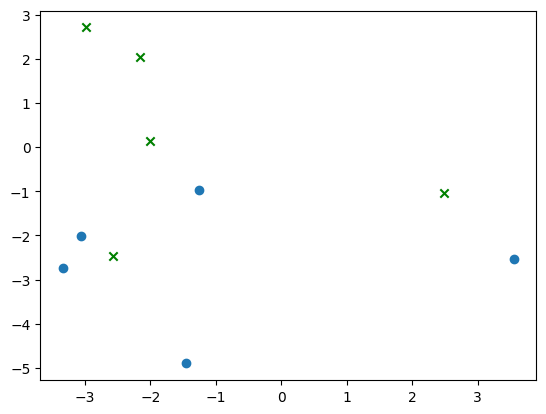

In [58]:
plot(random_2d_points(), random_2d_points())

In [59]:
candidates = [Candidate(id=id, position=random_2d_point()) for id in range(5)]
voters = [Voter(position=random_2d_point()) for _ in range(15)]
election = Election(candidates=candidates, voters=voters)

In [60]:
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
election_result = election.compare_strategies(strategies=strategies)

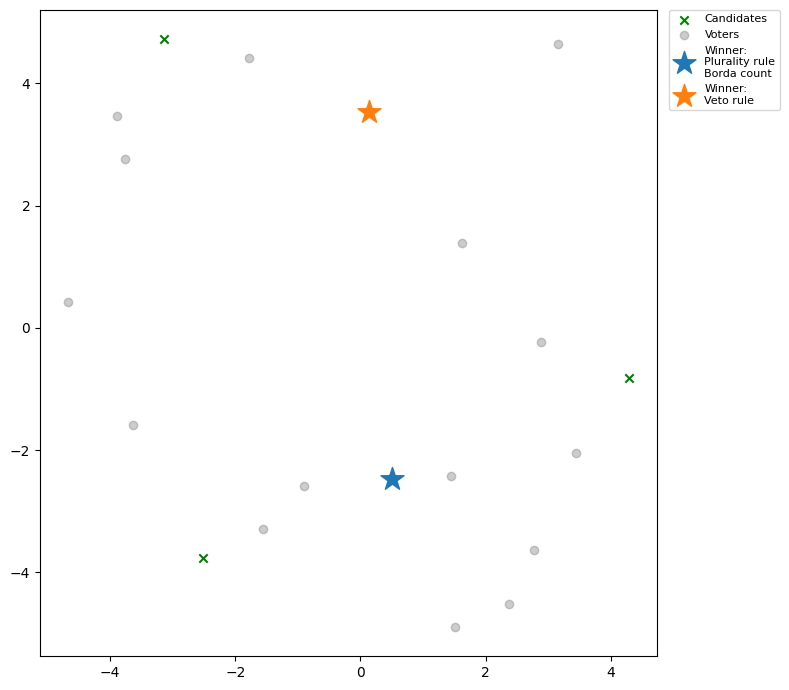

In [61]:
plot_results(election_result)

In [38]:
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
election_results: list[ElectionResult] = []

N = 1000
for _ in range(N):
    candidates = [Candidate(id=id, position=random_2d_point()) for id in range(5)]
    voters = [Voter(position=random_2d_point()) for _ in range(100)]
    election = Election(candidates=candidates, voters=voters)

    election_result = election.compare_strategies(strategies=strategies)
    election_results.append(election_result)

In [39]:
analyzer = ResultsAnalyzer(election_results)

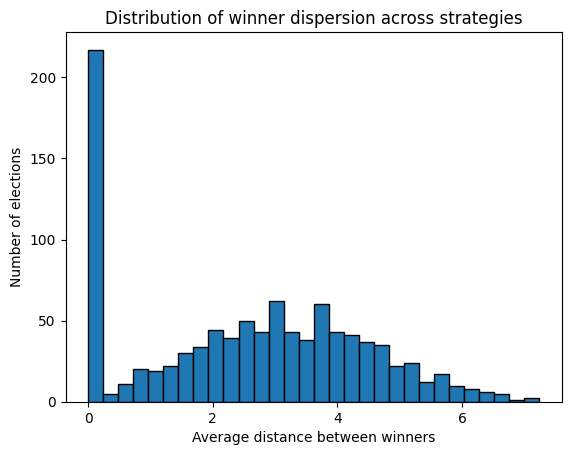

In [40]:
distances = analyzer.winner_distance_series()

plot_winner_distance_histogram(distances=distances, bins=30)

In [41]:
max_el_idx = np.argmax(distances)
min_el_idx = np.argmin(distances)

max_el, min_el = election_results[max_el_idx], election_results[min_el_idx]

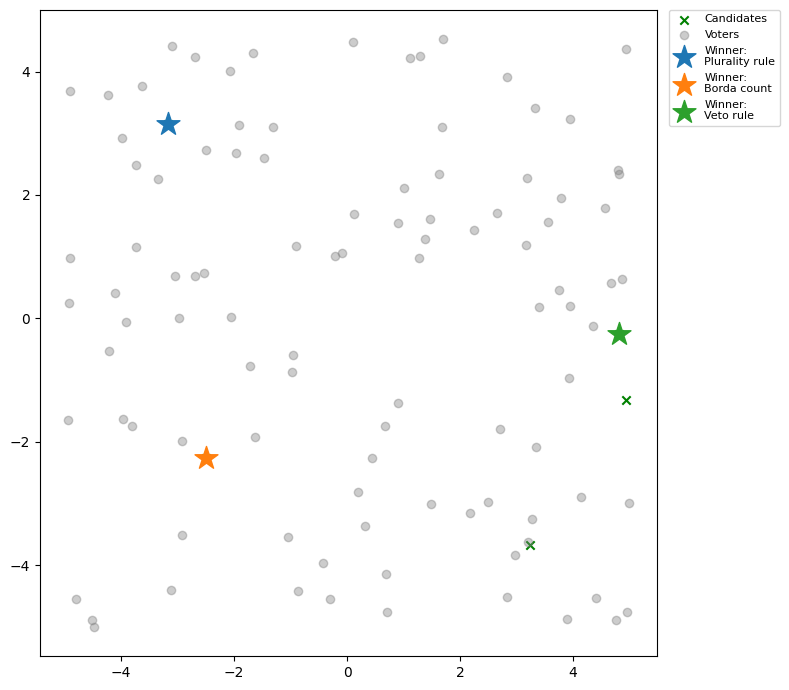

In [42]:
plot_results(max_el)

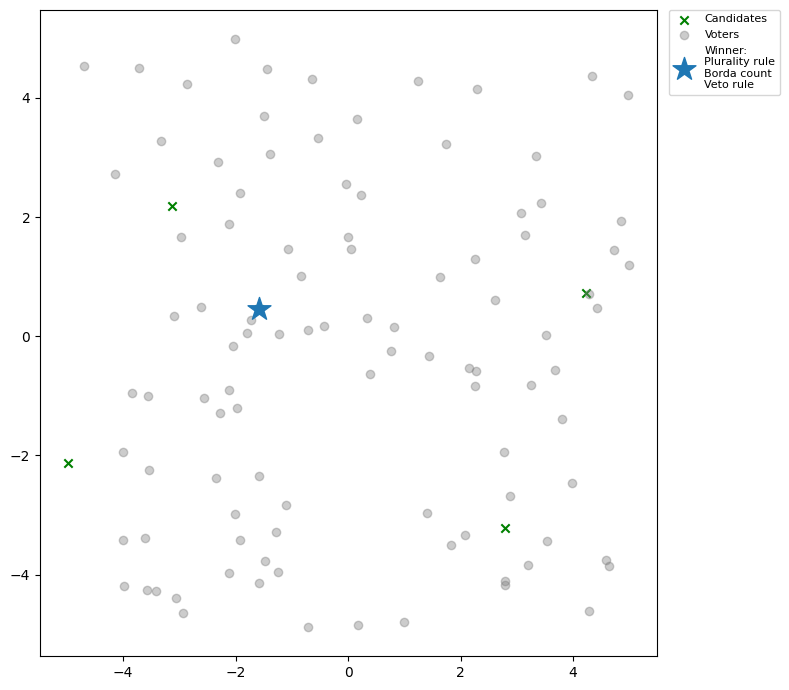

In [43]:
plot_results(min_el)